# **Error:** Downloading files

In [91]:
# Load packages
pkgs <- c("rstac", "httr", "sf", "lubridate", "jsonlite", "terra")
pkgs |>
  lapply(FUN = library, character.only = TRUE) |>
  invisible() |>
  suppressPackageStartupMessages()

# Set STAC endpoint parameters
mytoken <- Sys.getenv("NDC_TOKEN") # NOTE: replace with your token
headers <- add_headers("Authorization" = paste0("Bearer ", mytoken))
endpoint <- "https://ndc-test.containers.wur.nl/api/"

# Set date parameters
daterange <- paste(lapply(c("2026-01-01", "2026-01-31"),
                          FUN = function(x) format(as_datetime(x), "%Y-%m-%dT%H:%M:%SZ")),
                   collapse = "/")

# Import region-of-interest
veluwe <- st_read("../data/veluwe.gpkg", quiet = TRUE) |>
  st_as_sf() |>
  st_transform(4326) |>
  st_geometry()

# Set temporary directory
tmp <- tempdir()
print(tmp)

[1] "/tmp/Rtmpt1GuUp"


In [92]:
search <- stac(endpoint) |>
  stac_search(collections = "groenmonitor-geoserver",
              intersects = veluwe) |>
  post_request(headers)

In [93]:
items <- search |>
  items_fetch(headers, progress = FALSE) |>
  items_filter(properties$`ndc:observation_date` >= "2026-03-01",
               properties$`ndc:observation_date` <= "2026-03-31",
               "ndvi" %in% properties$`keywords`)

In [94]:
print(items)

###Items
- features (3 item(s)):
  - groenmonitor-geoserver-groenmonitor__ndvi_20260322
  - groenmonitor-geoserver-groenmonitor__ndvi_20260305
  - groenmonitor-geoserver-groenmonitor__ndvi_20260302
- assets: download, legend, thumbnail, wcs, wms
- item's fields: 
assets, bbox, collection, geometry, id, links, properties, stac_extensions, stac_version, type


In [139]:
wcs_urls <- assets_url(items, asset_names = "wcs")
item_ids <- vapply(items$features, function(f) f$id, character(1))
dest <- file.path(tmp, paste0(item_ids, ".tif"))
print(dest)

[1] "/tmp/Rtmpt1GuUp/groenmonitor-geoserver-groenmonitor__ndvi_20260322.tif"
[2] "/tmp/Rtmpt1GuUp/groenmonitor-geoserver-groenmonitor__ndvi_20260305.tif"
[3] "/tmp/Rtmpt1GuUp/groenmonitor-geoserver-groenmonitor__ndvi_20260302.tif"


In [136]:
for (i in 1:length(dest)) system(paste0("touch ", dest[i]))
print(list.files(path = tmp, pattern = "*", full.names = TRUE, recursive = TRUE))

download.file(url = wcs_urls[1], destfile = dest[1], mode = "wb")
#mapply(function(u, d) download.file(u, d, mode = "wb"), wcs_urls, dest)

[1] "/tmp/Rtmpt1GuUp/geoserver/ows"                                                           
[2] "/tmp/Rtmpt1GuUp/groenmonitor-geoserver-groenmonitor__ndvi_20260302.tif"                  
[3] "/tmp/Rtmpt1GuUp/groenmonitor-geoserver-groenmonitor__ndvi_20260305.tif"                  
[4] "/tmp/Rtmpt1GuUp/groenmonitor-geoserver-groenmonitor__ndvi_20260322.tif"                  
[5] "/tmp/Rtmpt1GuUp/items.json"                                                              
[6] "/tmp/Rtmpt1GuUp/positron-plot-renderings/render-fb4f51d8-4252-4212-9c81-4fb342ee5ff9.png"


trying URL 'https://data.groenmonitor.nl/geoserver/ows?service=WCS&version=2.0.1&request=GetCoverage&coverageId=groenmonitor%3Andvi_20260322&format=image%2Ftiff'
Warning message:
In download.file(url = wcs_urls[1], destfile = dest[1], mode = "wb") :
  URL 'https://data.groenmonitor.nl/geoserver/ows?service=WCS&version=2.0.1&request=GetCoverage&coverageId=groenmonitor%3Andvi_20260322&format=image%2Ftiff': Timeout of 60 seconds was reached


: [1m[33mError[39m in `download.file()`:[22m
[33m![39m cannot open URL 'https://data.groenmonitor.nl/geoserver/ows?service=WCS&version=2.0.1&request=GetCoverage&coverageId=groenmonitor%3Andvi_20260322&format=image%2Ftiff'

In [137]:
list.files(path = tmp,
           pattern = "*",
           full.names = TRUE,
           recursive = TRUE) |>
  print()

[1] "/tmp/Rtmpt1GuUp/geoserver/ows"                                                           
[2] "/tmp/Rtmpt1GuUp/groenmonitor-geoserver-groenmonitor__ndvi_20260302.tif"                  
[3] "/tmp/Rtmpt1GuUp/groenmonitor-geoserver-groenmonitor__ndvi_20260305.tif"                  
[4] "/tmp/Rtmpt1GuUp/items.json"                                                              
[5] "/tmp/Rtmpt1GuUp/positron-plot-renderings/render-fb4f51d8-4252-4212-9c81-4fb342ee5ff9.png"


Only be one raster file seems to be present in the download folder ("geoserver/ows"):

In [51]:
r <- rast(paste0(tmp, "/geoserver/ows"))

print(r)

Warning message:
[rast] unknown extent 


class       : SpatRaster 
dimensions  : 1024, 1024, 4  (nrow, ncol, nlyr)
resolution  : 1, 1  (x, y)
extent      : 0, 1024, 0, 1024  (xmin, xmax, ymin, ymax)
coord. ref. :  
source      : ows 
names       : ows_1, ows_2, ows_3, ows_4 


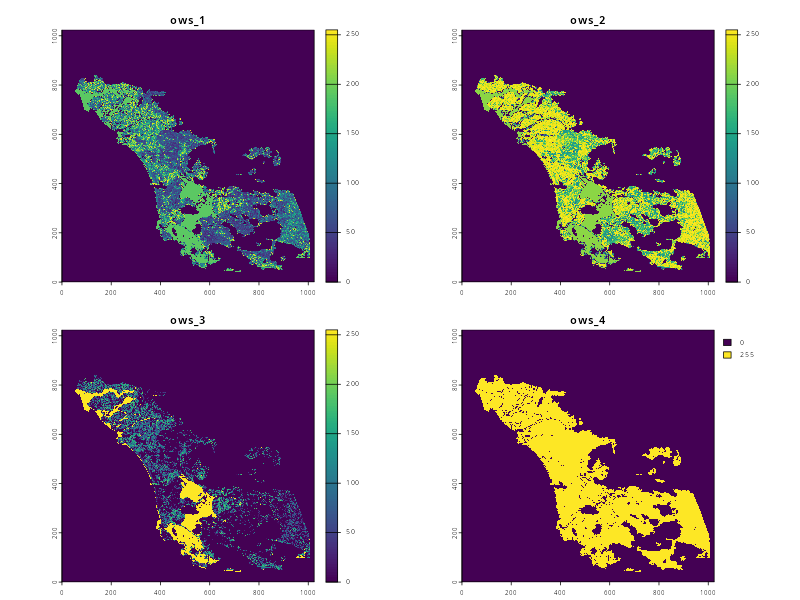

In [52]:
plot(r)